In [1]:
%env DB_PASSWORD=5J8DhII0RRsPW1

env: DB_PASSWORD=5J8DhII0RRsPW1


In [2]:
import pandas as pd
import re
from constants.db_connections import ENGINE_READ_ONLY
import os
import paramiko


pd.reset_option('display.float_format')

In [3]:

# Set your server details
hostname = 'dandyweb01fl'  # Replace with your server's IP or hostname
port = 22                       # Usually 22 for SSH
username = 'glj523'      # Replace with your username
password = 'Wtcantfw36c!123'      # Replace with your password

remote_directories = ['/datasets/caeg_fastq/2023/20230927_A00706_0773_AHNLW5DSX5_AOZCK/eDNALib060-Kurt',
                      '/datasets/caeg_fastq/2023/20230927_A00706_0773_AHNLW5DSX5_AOZCK/eDNALib060-Thorfinn',
                      '/datasets/caeg_fastq/2024/20240702_A00706_0862_BH5F5KDSX7_WBDQ4_new/ssDNALib0019']

lib_ids_all = {}

remote_directory = remote_directories[0]  # Replace with the directory you want to list


# Create an SSH client
ssh = paramiko.SSHClient()
ssh.set_missing_host_key_policy(paramiko.AutoAddPolicy())

try:
    # Connect to the server
    ssh.connect(hostname, port, username, password)

    # Run the command to list files and directories

    for dir in remote_directories:
    
        stdin, stdout, stderr = ssh.exec_command(f"ls {dir} | grep '\.fastq.*$'")

        _, test, _ = ssh.exec_command(f"ls {dir} | grep '\.fastq.*$' | wc -l")
    

        # Process the output
        file_names = stdout.read().decode().splitlines()
        test = test.read().decode()

        lib_ids = [file_name.split("-")[0] for file_name in file_names]

        if int(test) != len(lib_ids):
            raise Exception("Error")

        lib_ids_all[dir.split("/")[-1]] = list(set(lib_ids))
    

        # Print the first 8 letters of each file/directory name
   

except Exception as e:
    print(f"An error occurred: {e}")

finally:
    # Close the connection
    ssh.close()

df = pd.read_sql(sql='select * from test_1.mega_table_qc_split_mat', con=ENGINE_READ_ONLY)
abi_data = pd.read_csv(r"c:\Users\glj523\Downloads\CambodiaLibs - cambodia_libs.tsv", sep="\t")

In [4]:
kurt = lib_ids_all["eDNALib060-Kurt"]
thorf = lib_ids_all["eDNALib060-Thorfinn"]
sslib = lib_ids_all["ssDNALib0019"]

cols = ['library_id', 
        'qc_type',
        'sample_name',
        'fastqc_raw__Total Sequences',
        'fastqc_trimmed__Total Sequences',
        r'fastqc_raw__%GC',
        r'fastqc_trimmed__%GC',
        'fastp__insert_size',
        'samtools_stats__reads_mapped']

sslib_qc = df[df["library_id"].isin(sslib)][cols]
thorf_qc = df[df["library_id"].isin(thorf)][cols]
kurt_qc = df[df["library_id"].isin(kurt)][cols]

if sslib_qc["sample_name"].duplicated().sum() != 0:
    raise Exception()
if (sslib_qc["library_id"] + "_" + sslib_qc["qc_type"]).duplicated().sum() != 0:
    raise Exception()

qc_types_raw = ['L001_R1', 'L002_R1', 'L003_R1', 'L004_R1', 'L001_R2', 'L002_R2', 'L003_R2', 'L004_R2']
qc_types_collapsed = ['L001_collapsed', 'L002_collapsed', 'L003_collapsed','L004_collapsed']
qc_types_singleton = ['L001_singleton', 'L002_singleton', 'L003_singleton', 'L004_singleton']

dummydata_1 = pd.concat([sslib_qc, sslib_qc])
dummydata_2 = pd.concat([dummydata_1, sslib_qc])
dummydata_3 = pd.concat([dummydata_2, sslib_qc])
dummydata_4 = pd.concat([dummydata_3, sslib_qc])

In [185]:
def make_sum_plot(col_to_sum, qc_types, logy):
        machine1_data = [thorf_qc, kurt_qc, sslib_qc]
        machine2_data = [thorf_qc, kurt_qc, sslib_qc]
        machine3_data = [thorf_qc, kurt_qc, sslib_qc]
        data_labels = ["thorfinn_data", "kurt_data", "ss_data"]


        data = {"Data": data_labels,
                "Machine 1": [df[df["qc_type"].isin(qc_types)][col_to_sum].sum() for df in machine1_data],
                "Machine 2": [df[df["qc_type"].isin(qc_types)][col_to_sum].sum() for df in machine2_data],
                "Machine 3": [df[df["qc_type"].isin(qc_types)][col_to_sum].sum() for df in machine3_data]}


        res = pd.DataFrame(data)
        return res.plot(kind="bar", x="Data", y=["Machine 1", "Machine 2", "Machine 3"], ylabel=col_to_sum, title=col_to_sum, rot=30, logy=logy)

In [6]:
sum_cols = ["fastqc_raw__Total Sequences", "fastqc_trimmed__Total Sequences", "samtools_stats__reads_mapped"]

Raw sums

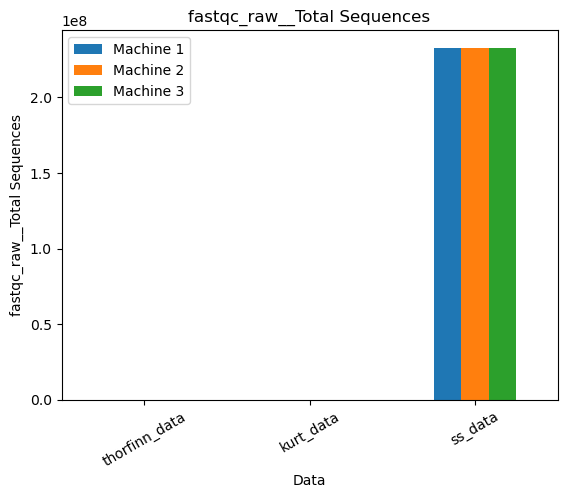

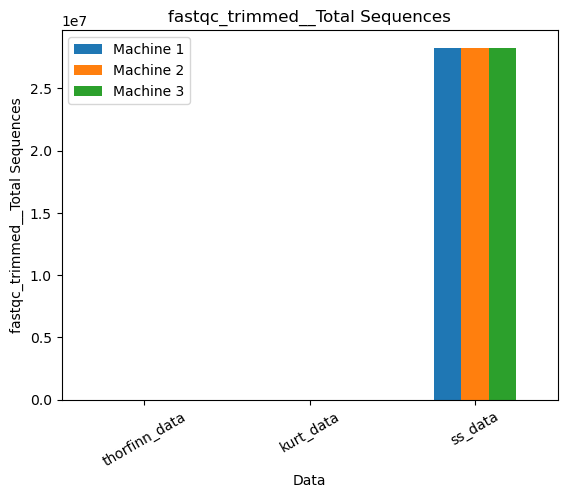

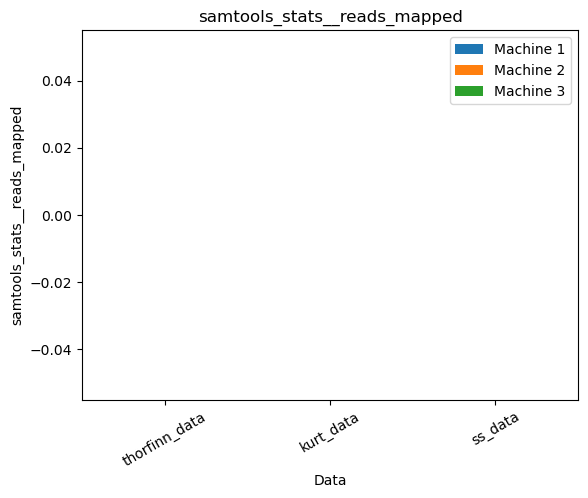

In [186]:
for sum_col in sum_cols:
    make_sum_plot(sum_col, qc_types_raw, logy=False)

Other stuff


In [145]:
describe_cols = [r"fastqc_raw__%GC", r"fastqc_trimmed__%GC"]

In [161]:
def make_describe_plot(col, logy, data, include_count=False):
    for k, v in data.items():
        
        if include_count:
            data = {k: v[col].describe() for k, v in v.items()}
            
        else:
            data = {k: v[col].describe().iloc[1:] for k, v in v.items()}

        res = pd.DataFrame(data)
  
        res.plot(kind="bar", rot=30, logy=logy, title=k, ylabel=col)

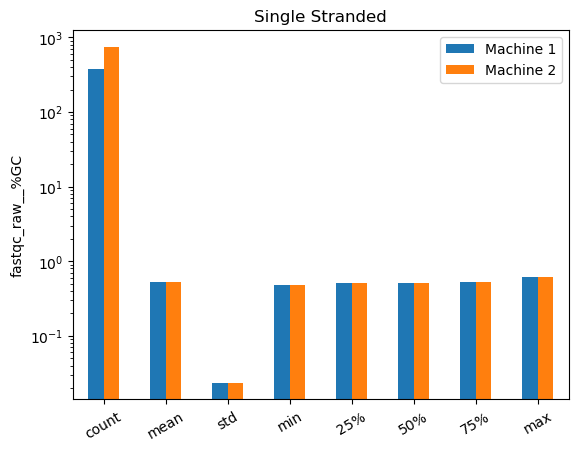

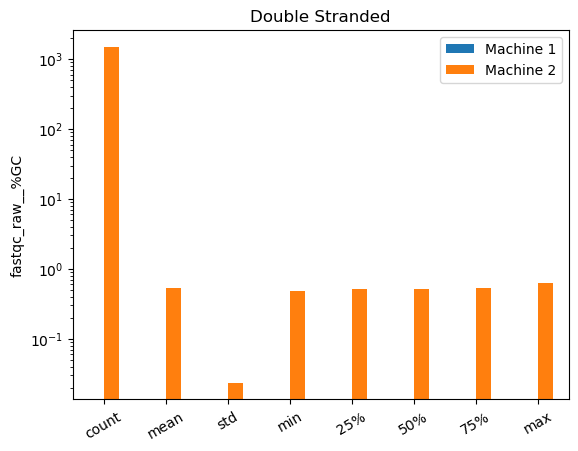

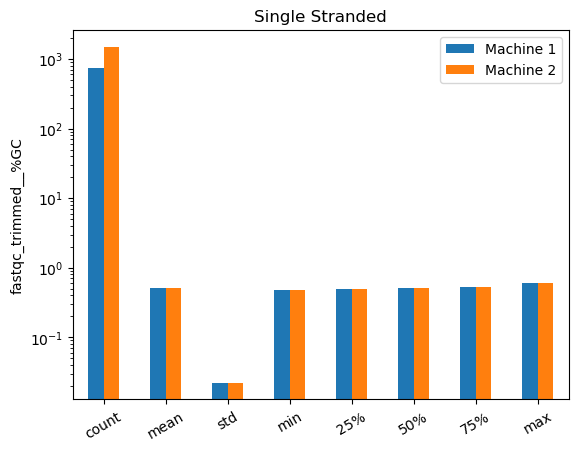

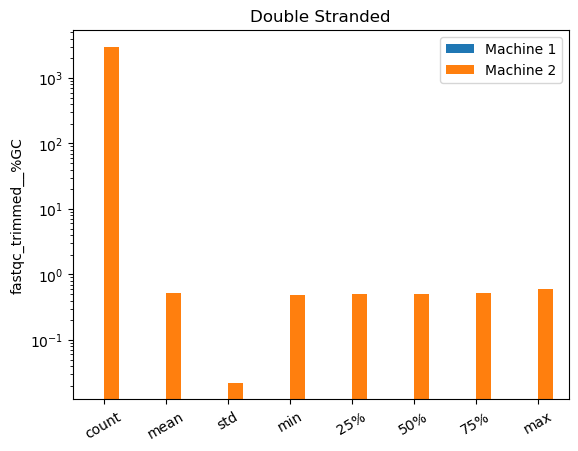

In [187]:
machine_1_ss = sslib_qc
machine_2_ss = dummydata_1
machine_1_ds = pd.concat([thorf_qc, kurt_qc])
machine_2_ds = dummydata_3

data = {"Single Stranded": {"Machine 1": machine_1_ss,
                            "Machine 2": machine_2_ss},
        "Double Stranded": {"Machine 1": machine_1_ds,
                            "Machine 2": machine_2_ds}
        }

for cols in describe_cols:

        make_describe_plot(cols, True, data, include_count=True)

Single Stranded
Double Stranded


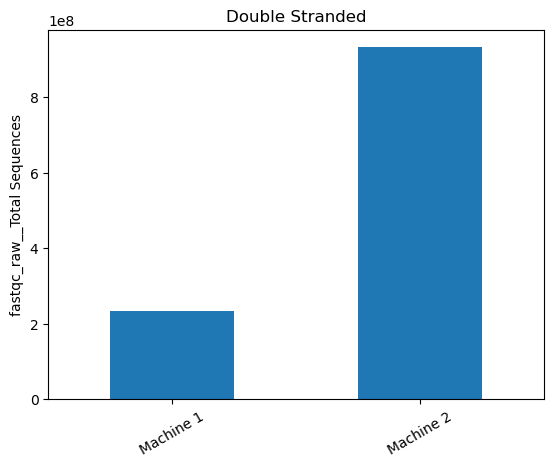

In [207]:

        
        
def make_sum_plot(col_to_sum, qc_types, logy):
        machine1_data = [thorf_qc, kurt_qc, sslib_qc]
        machine2_data = [thorf_qc, kurt_qc, sslib_qc]
        machine3_data = [thorf_qc, kurt_qc, sslib_qc]
        data_labels = ["thorfinn_data", "kurt_data", "ss_data"]


        data = {"Data": data_labels,
                "Machine 1": [df[df["qc_type"].isin(qc_types)][col_to_sum].sum() for df in machine1_data],
                "Machine 2": [df[df["qc_type"].isin(qc_types)][col_to_sum].sum() for df in machine2_data],
                "Machine 3": [df[df["qc_type"].isin(qc_types)][col_to_sum].sum() for df in machine3_data]}


        res = pd.DataFrame(data)
        return res.plot(kind="bar", x="Data", y=["Machine 1", "Machine 2", "Machine 3"], ylabel=col_to_sum, title=col_to_sum, rot=30, logy=logy)
    
    
def make_sum_plot(col, logy, data, include_count=False):
    
    
    for k, v in data.items():
        
        print(k)
    
        data = {k: v[col].sum() for k, v in v.items()}
        
        res = pd.Series(data)
  
        res.plot(kind="bar", rot=30, logy=logy, title=k, ylabel=col)

data_ = {"Single Stranded": {"Machine 1": machine_1_ss,
                            "Machine 2": machine_2_ss},
        "Double Stranded": {"Machine 1": machine_1_ds,
                            "Machine 2": machine_2_ds}
        }



make_sum_plot(sum_cols[0], False, data_)
        


In [196]:
data = {"Single Stranded": {"Machine 1": "machine_1_ss",
                            "Machine 2": "machine_2_ss"},
        "Double Stranded": {"Machine 1": "machine_1_ds",
                            "Machine 2": "machine_2_ds"}
        }

In [200]:
for k, v in data.items():
    print(k)
    print({k: v + "[col].sum()" for k, v in v.items()}
)

Single Stranded
{'Machine 1': 'machine_1_ss[col].sum()', 'Machine 2': 'machine_2_ss[col].sum()'}
Double Stranded
{'Machine 1': 'machine_1_ds[col].sum()', 'Machine 2': 'machine_2_ds[col].sum()'}
